# Experiment 3 – Inference Steps Sweep (Perceptual Metrics)

This notebook replaces weak single-image scoring with stronger **batch-level** evaluation for WikiArt inference-step sweeps.

## Why this notebook exists

The earlier CLIP + FID setup could still reward obviously bad outputs, especially at extreme step counts, because:

- CLIP measured prompt alignment but not visible image quality
- FID was computed on a small batch and is noisy at small sample sizes
- a single display image is not a reliable basis for model selection

## What is different here

For each tested inference step count, this notebook:

1. generates a **matched batch** using fixed seeds
2. computes **batch CLIP alignment** instead of scoring one image
3. computes **LPIPS and SSIM against matched real WikiArt references**
4. computes **KID and FID** against the real style subset
5. adds **style-confidence and artifact-sensitive signals** so noisy outputs are penalized
6. builds a **composite ranking** and then checks it visually

## 1. Setup and Configuration

Import project modules and metric libraries, define absolute paths, configure device selection, output folders, cache folders, and reproducibility settings.

In [1]:
from pathlib import Path
import importlib
import json
import math
import os
import random
import shutil
import subprocess
import sys
from collections import defaultdict

PROJECT_ROOT = Path("/home/doshlom4/work/final_project")
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

os.environ["HF_HOME"] = str(PROJECT_ROOT / "dataset_cache" / "huggingface")
os.environ["TRANSFORMERS_CACHE"] = str(PROJECT_ROOT / "dataset_cache" / "huggingface" / "transformers")
print(f"HF_HOME: {os.environ['HF_HOME']}")


def _ensure(pkg: str, import_as: str | None = None) -> None:
    module_name = import_as or pkg.split("[")[0].replace("-", "_")
    if importlib.util.find_spec(module_name) is None:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
    else:
        print(f"✓ {pkg} available")


_ensure("scikit-image", "skimage")
_ensure("lpips")
_ensure("torchmetrics[image]", "torchmetrics")
_ensure("torch-fidelity", "torch_fidelity")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from skimage.metrics import structural_similarity as ssim_fn
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from tqdm import tqdm
import lpips

from diffusers import DDPMScheduler
from transformers import CLIPModel, CLIPProcessor, CLIPTextModel, CLIPTokenizer

from config import (
    CLIP_MODEL_NAME,
    EXPERIMENT_3_CONFIG,
    EXPERIMENT_3_DATASET_DIR,
    EXPERIMENT_3_DIR,
    INFERENCE_CONFIG,
    TOKENIZER_MAX_LENGTH,
    WIKIART_STYLES,
    get_latest_wikiart_unet_checkpoint,
    get_style_dir,
)
from wikiart_classifier import load_wikiart_classifier, get_wikiart_transforms

USE_GPU = True
device = torch.device("cuda" if USE_GPU and torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

OUTPUT_DIR = EXPERIMENT_3_DIR / "inference_steps_sweep_perceptual_metrics"
GENERATED_DIR = OUTPUT_DIR / "generated"
REFERENCE_DIR = OUTPUT_DIR / "reference"
PLOTS_DIR = OUTPUT_DIR / "plots"
TABLES_DIR = OUTPUT_DIR / "tables"
for path in [OUTPUT_DIR, GENERATED_DIR, REFERENCE_DIR, PLOTS_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Output dir: {OUTPUT_DIR}")

Project root: /home/doshlom4/work/final_project
HF_HOME: /home/doshlom4/work/final_project/dataset_cache/huggingface
✓ scikit-image available
✓ lpips available
✓ torchmetrics[image] available
✓ torch-fidelity available


/home/doshlom4/work/conda/envs/shlomid_conda_12_11_2025/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/doshlom4/work/conda/envs/shlomid_conda_12_11_2025/lib/python3.10/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


Device: cuda
NVIDIA A100 80GB PCIe
Output dir: /home/doshlom4/work/final_project/outputs/experiment_3/inference_steps_sweep_perceptual_metrics


## 2. Load Diffusion and Metric Models

Load the trained WikiArt UNet, tokenizer, text encoder, CLIP scorer, WikiArt classifier, scheduler configuration, and perceptual metric models.

In [2]:
from models.custom_unet_wikiart import CustomUNet2DConditionModelWikiArt

checkpoint_path = get_latest_wikiart_unet_checkpoint()
checkpoint = torch.load(str(checkpoint_path), map_location=device)
unet = CustomUNet2DConditionModelWikiArt().to(device)
if isinstance(checkpoint, dict):
    if "unet_state_dict" in checkpoint:
        unet.load_state_dict(checkpoint["unet_state_dict"])

    elif "model_state_dict" in checkpoint:
        unet.load_state_dict(checkpoint["model_state_dict"])

    elif "state_dict" in checkpoint:
        unet.load_state_dict(checkpoint["state_dict"])

    else:
        unet.load_state_dict(checkpoint)

    checkpoint_epoch = checkpoint.get("epoch", "unknown")
else:
    unet.load_state_dict(checkpoint)
    checkpoint_epoch = "unknown"
unet.eval()

text_encoder = CLIPTextModel.from_pretrained(CLIP_MODEL_NAME).to(device)
text_encoder.eval()
tokenizer = CLIPTokenizer.from_pretrained(CLIP_MODEL_NAME)

clip_model = CLIPModel.from_pretrained(CLIP_MODEL_NAME).to(device)
clip_model.eval()
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)

lpips_fn = lpips.LPIPS(net="alex").to(device)
lpips_fn.eval()

classifier = None
classifier_checkpoint = {}
classifier_transform = None
classifier_available = False
try:
    classifier, classifier_checkpoint = load_wikiart_classifier(device=device)
    classifier.eval()
    _, classifier_transform = get_wikiart_transforms(image_size=128)
    classifier_available = True
except FileNotFoundError as exc:
    print(f"WikiArt classifier checkpoint not found; classifier-based metrics will be skipped: {exc}")
except Exception as exc:
    print(f"WikiArt classifier load failed; classifier-based metrics will be skipped: {exc}")

optional_iqa = {}
try:
    pyiqa_module = importlib.import_module("pyiqa")
    available_iqa_models = set(pyiqa_module.list_models())
    if "musiq" in available_iqa_models:
        optional_iqa["musiq"] = pyiqa_module.create_metric("musiq", device=device)
    if "nima" in available_iqa_models:
        optional_iqa["nima"] = pyiqa_module.create_metric("nima", device=device)
    print(f"Loaded optional IQA metrics: {sorted(optional_iqa.keys())}")
except Exception as exc:
    print(f"Optional no-reference IQA skipped: {exc}")

scheduler_config = {
    "beta_schedule": INFERENCE_CONFIG["beta_schedule"],
    "num_train_timesteps": INFERENCE_CONFIG["num_train_timesteps"],
}

print(f"UNet checkpoint: {checkpoint_path}")
print(f"Checkpoint epoch: {checkpoint_epoch}")
print(f"Classifier available: {classifier_available}")
if classifier_available:
    print(f"Classifier test acc: {classifier_checkpoint.get('test_acc', 'N/A')}")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/doshlom4/work/conda/envs/shlomid_conda_12_11_2025/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/doshlom4/work/conda/envs/shlomid_conda_12_11_2025/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/doshlom4/work/conda/envs/shlomid_conda_12_11_2025/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
WikiArt classifier checkpoint not found; classifier-based metrics will be skipped: [Errno 2] No such file or directory: '/home/doshlom4/work/final_project/checkpoints/wikiart_classifier.pt'
Optional no-reference IQA skipped: No module named 'pyiqa'
UNet checkpoint: /home/doshlom4/work/final_project/checkpoints/wikiart_unet_checkpoint_epoch_189.pt
Checkpoint epoch: unknown
Classifier available: False


## 3. Define Step Sweep and Evaluation Sampling

Declare the tested inference steps, the fixed style prompt, the seed schedule, generated batch size, and the real-image reference subset used for every comparison.

In [3]:
INFERENCE_STEPS_LIST = [1, 5, 10, 20, 50, 100, 200, 250, 300, 350]
FIXED_STYLE = "Impressionism"
FIXED_STYLE_IDX = WIKIART_STYLES.index(FIXED_STYLE)
FIXED_PROMPT = EXPERIMENT_3_CONFIG["prompt_template"].format(
    style_name=FIXED_STYLE.replace("_", " ")
)
GUIDANCE_SCALE = 1.0
DISPLAY_SEED = 42
EVAL_SEEDS = list(range(10_000, 10_016))
REAL_REFERENCE_LIMIT = 64
VISUAL_COMPARE_COUNT = 4

REAL_STYLE_DIR = get_style_dir(EXPERIMENT_3_DATASET_DIR, FIXED_STYLE_IDX)
REFERENCE_FLAT_DIR = REFERENCE_DIR / FIXED_STYLE.lower()

print(f"Prompt: {FIXED_PROMPT}")
print(f"Style index: {FIXED_STYLE_IDX}")
print(f"Guidance scale: {GUIDANCE_SCALE}")
print(f"Step sweep: {INFERENCE_STEPS_LIST}")
print(f"Eval seeds: {EVAL_SEEDS[0]}..{EVAL_SEEDS[-1]} ({len(EVAL_SEEDS)} images)")
print(f"Real style dir: {REAL_STYLE_DIR}")

Prompt: A painting in the style of Impressionism
Style index: 12
Guidance scale: 1.0
Step sweep: [1, 5, 10, 20, 50, 100, 200, 250, 300, 350]
Eval seeds: 10000..10015 (16 images)
Real style dir: /home/doshlom4/work/final_project/outputs/experiment_3/dataset/style_12_Impressionism


## 4. Implement Image Generation and Caching Helpers

Create deterministic generation helpers, disk caching, image conversion utilities, and safe directory preparation so the notebook can be resumed without regenerating everything.

In [4]:
def maybe_reset_dir(path: Path, reset: bool = False) -> None:
    if reset and path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def image_tensor_to_uint8(image_tensor: torch.Tensor) -> torch.Tensor:
    return (image_tensor.clamp(0, 1) * 255.0).round().to(torch.uint8)


def image_tensor_to_pil(image_tensor: torch.Tensor) -> Image.Image:
    image_np = image_tensor.clamp(0, 1).permute(1, 2, 0).cpu().numpy()
    return Image.fromarray((image_np * 255.0).round().astype(np.uint8))


def save_tensor_image(image_tensor: torch.Tensor, output_path: Path) -> None:
    image_tensor_to_pil(image_tensor).save(output_path)


def load_image_tensor(image_path: Path) -> torch.Tensor:
    image = Image.open(image_path).convert("RGB")
    image_np = np.asarray(image).astype(np.float32) / 255.0
    return torch.from_numpy(image_np).permute(2, 0, 1)


def get_step_dir(num_steps: int) -> Path:
    return GENERATED_DIR / f"steps_{num_steps:03d}"


def get_step_metadata_path(num_steps: int) -> Path:
    return get_step_dir(num_steps) / "metadata.json"


@torch.no_grad()
def _encode_prompt(prompt: str) -> torch.Tensor:
    text_input = tokenizer(
        [prompt],
        padding="max_length",
        max_length=TOKENIZER_MAX_LENGTH,
        truncation=True,
        return_tensors="pt",
    )
    text_emb = text_encoder(text_input.input_ids.to(device))[0]

    uncond_input = tokenizer(
        [""],
        padding="max_length",
        max_length=TOKENIZER_MAX_LENGTH,
        return_tensors="pt",
    )
    uncond_emb = text_encoder(uncond_input.input_ids.to(device))[0]
    return torch.cat([uncond_emb, text_emb], dim=0)


@torch.no_grad()
def generate_single(prompt: str, num_inference_steps: int, seed: int, guidance_scale: float) -> torch.Tensor:
    text_emb = _encode_prompt(prompt)
    generator = torch.Generator(device=device.type).manual_seed(seed)
    latents = torch.randn((1, 3, 128, 128), generator=generator, device=device)

    scheduler = DDPMScheduler(**scheduler_config)
    scheduler.set_timesteps(num_inference_steps)

    for timestep in scheduler.timesteps:
        latent_model_input = torch.cat([latents, latents], dim=0)
        latent_model_input = scheduler.scale_model_input(latent_model_input, timestep)
        noise_pred = unet(latent_model_input, timestep, encoder_hidden_states=text_emb).sample
        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)
        latents = scheduler.step(noise_pred, timestep, latents).prev_sample

    return (latents[0] / 2 + 0.5).clamp(0, 1).cpu()


def generate_batch_cached(prompt: str, num_steps: int, seeds: list[int], guidance_scale: float) -> tuple[list[Path], dict]:
    step_dir = get_step_dir(num_steps)
    maybe_reset_dir(step_dir, reset=False)
    image_paths = []

    for seed in tqdm(seeds, desc=f"Generate {num_steps} steps", leave=False):
        output_path = step_dir / f"seed_{seed}.png"
        if not output_path.exists():
            image_tensor = generate_single(prompt, num_inference_steps=num_steps, seed=seed, guidance_scale=guidance_scale)
            save_tensor_image(image_tensor, output_path)
        image_paths.append(output_path)

    metadata = {
        "prompt": prompt,
        "style": FIXED_STYLE,
        "num_steps": num_steps,
        "guidance_scale": guidance_scale,
        "seeds": seeds,
        "image_paths": [str(path) for path in image_paths],
    }
    get_step_metadata_path(num_steps).write_text(json.dumps(metadata, indent=2))
    return image_paths, metadata

## 5. Prepare Real-Image Reference Batches

Collect a fixed subset of real WikiArt images from the selected style, flatten them into a single directory, and prepare reusable tensors and CLIP features for nearest-reference matching.

In [5]:
if not REAL_STYLE_DIR.exists():
    raise FileNotFoundError(f"Real style directory not found: {REAL_STYLE_DIR}")

real_image_paths = sorted([
    *REAL_STYLE_DIR.glob("*.png"),
    *REAL_STYLE_DIR.glob("*.jpg"),
    *REAL_STYLE_DIR.glob("*.jpeg"),
])
if len(real_image_paths) < len(EVAL_SEEDS):
    raise RuntimeError(
        f"Need at least {len(EVAL_SEEDS)} real images for matching, found {len(real_image_paths)}"
    )

maybe_reset_dir(REFERENCE_FLAT_DIR, reset=True)
real_image_paths = real_image_paths[:REAL_REFERENCE_LIMIT]
reference_paths = []
for idx, image_path in enumerate(real_image_paths):
    target_path = REFERENCE_FLAT_DIR / f"real_{idx:04d}{image_path.suffix.lower()}"
    target_path.symlink_to(image_path.resolve())
    reference_paths.append(target_path)

real_tensors = [load_image_tensor(path) for path in tqdm(reference_paths, desc="Load real refs", leave=False)]
real_clip_inputs = clip_processor(images=[image_tensor_to_pil(tensor) for tensor in real_tensors], return_tensors="pt")
real_clip_inputs = {key: value.to(device) for key, value in real_clip_inputs.items()}
with torch.no_grad():
    real_clip_features = F.normalize(clip_model.get_image_features(**real_clip_inputs), dim=-1)

print(f"Prepared {len(reference_paths)} real reference images in {REFERENCE_FLAT_DIR}")

Prepared 50 real reference images in /home/doshlom4/work/final_project/outputs/experiment_3/inference_steps_sweep_perceptual_metrics/reference/impressionism


## 6. Generate Evaluation Batches for Each Step Count

Generate matched image batches for every tested step count with the same prompt and seed schedule. Save metadata so the results are reproducible and resumable.

In [6]:
generated_batches = {}
metadata_by_steps = {}

for num_steps in INFERENCE_STEPS_LIST:
    image_paths, metadata = generate_batch_cached(
        FIXED_PROMPT,
        num_steps=num_steps,
        seeds=EVAL_SEEDS,
        guidance_scale=GUIDANCE_SCALE,
    )
    generated_batches[num_steps] = image_paths
    metadata_by_steps[num_steps] = metadata

print(f"Prepared cached batches for {len(generated_batches)} step counts.")

Prepared cached batches for 10 step counts.


## 7. Compute Prompt-Alignment Metrics

Compute prompt alignment over the full generated batch using CLIP text-image similarity. Also record WikiArt classifier style confidence and entropy as a second alignment signal.

In [7]:
with torch.no_grad():
    text_inputs = clip_processor(text=[FIXED_PROMPT], return_tensors="pt", padding=True)
    text_inputs = {key: value.to(device) for key, value in text_inputs.items()}
    text_features = F.normalize(clip_model.get_text_features(**text_inputs), dim=-1)

alignment_results = {}
classifier_results = {}
generated_clip_features_by_steps = {}

for num_steps, image_paths in generated_batches.items():
    image_tensors = [load_image_tensor(path) for path in image_paths]
    pil_images = [image_tensor_to_pil(tensor) for tensor in image_tensors]

    clip_inputs = clip_processor(images=pil_images, return_tensors="pt")
    clip_inputs = {key: value.to(device) for key, value in clip_inputs.items()}
    with torch.no_grad():
        image_features = F.normalize(clip_model.get_image_features(**clip_inputs), dim=-1)
    generated_clip_features_by_steps[num_steps] = image_features

    clip_scores = (image_features * text_features).sum(dim=-1).detach().cpu().numpy()
    alignment_results[num_steps] = {
        "clip_mean": float(np.mean(clip_scores)),
        "clip_std": float(np.std(clip_scores)),
    }

    if classifier_available and classifier is not None and classifier_transform is not None:
        classifier_batch = torch.stack([
            classifier_transform(image_tensor_to_pil(tensor))
            for tensor in image_tensors
        ]).to(device)
        with torch.no_grad():
            classifier_logits = classifier(classifier_batch)
            classifier_probs = classifier_logits.softmax(dim=-1)
            target_probs = classifier_probs[:, FIXED_STYLE_IDX]
            entropy = -(classifier_probs * torch.log(classifier_probs.clamp_min(1e-8))).sum(dim=-1)

        classifier_results[num_steps] = {
            "style_conf_mean": float(target_probs.mean().item()),
            "style_conf_std": float(target_probs.std(unbiased=False).item()),
            "entropy_mean": float(entropy.mean().item()),
        }
    else:
        classifier_results[num_steps] = {
            "style_conf_mean": math.nan,
            "style_conf_std": math.nan,
            "entropy_mean": math.nan,
        }

pd.DataFrame({
    "steps": INFERENCE_STEPS_LIST,
    "clip_mean": [alignment_results[s]["clip_mean"] for s in INFERENCE_STEPS_LIST],
    "clip_std": [alignment_results[s]["clip_std"] for s in INFERENCE_STEPS_LIST],
    "style_conf_mean": [classifier_results[s]["style_conf_mean"] for s in INFERENCE_STEPS_LIST],
    "entropy_mean": [classifier_results[s]["entropy_mean"] for s in INFERENCE_STEPS_LIST],
})

,steps,clip_mean,clip_std,style_conf_mean,entropy_mean
0,1,0.238529,0.005884,NaN,NaN
1,5,0.256318,0.020163,NaN,NaN
2,10,0.256282,0.012976,NaN,NaN
3,20,0.268706,0.020587,NaN,NaN
4,50,0.286904,0.017980,NaN,NaN
5,100,0.269293,0.015101,NaN,NaN
6,200,0.270620,0.026193,NaN,NaN
7,250,0.261374,0.021276,NaN,NaN
8,300,0.279537,0.018342,NaN,NaN
9,350,0.258758,0.007391,NaN,NaN


## 8. Compute Perceptual-Quality Metrics

Match each generated image to its nearest real WikiArt reference in CLIP image-embedding space, then compute LPIPS and SSIM on the matched pair. If optional no-reference IQA is available, compute it too. Add a simple artifact penalty from total variation and clipping ratio so noisy outputs are penalized.

In [8]:
def to_lpips_input(image_tensor: torch.Tensor) -> torch.Tensor:
    return image_tensor.unsqueeze(0).to(device) * 2.0 - 1.0


def compute_total_variation(image_tensor: torch.Tensor) -> float:
    tv_h = torch.abs(image_tensor[:, 1:, :] - image_tensor[:, :-1, :]).mean()
    tv_w = torch.abs(image_tensor[:, :, 1:] - image_tensor[:, :, :-1]).mean()
    return float((tv_h + tv_w).item())


def compute_clipping_ratio(image_tensor: torch.Tensor) -> float:
    clipped = ((image_tensor <= 0.01) | (image_tensor >= 0.99)).float().mean()
    return float(clipped.item())


perceptual_results = defaultdict(dict)

for num_steps, image_paths in tqdm(generated_batches.items(), desc="Perceptual metrics"):
    image_tensors = [load_image_tensor(path) for path in image_paths]
    clip_features = generated_clip_features_by_steps[num_steps]
    similarity = clip_features @ real_clip_features.T
    nearest_indices = similarity.argmax(dim=1).detach().cpu().tolist()

    lpips_values = []
    ssim_values = []
    tv_values = []
    clipping_values = []
    musiq_values = []
    nima_values = []

    for image_tensor, ref_idx in zip(image_tensors, nearest_indices):
        ref_tensor = real_tensors[ref_idx]
        with torch.no_grad():
            lpips_value = lpips_fn(to_lpips_input(image_tensor), to_lpips_input(ref_tensor))
        lpips_values.append(float(lpips_value.item()))

        image_np = image_tensor.permute(1, 2, 0).numpy()
        ref_np = ref_tensor.permute(1, 2, 0).numpy()
        ssim_values.append(float(ssim_fn(image_np, ref_np, channel_axis=2, data_range=1.0)))

        tv_values.append(compute_total_variation(image_tensor))
        clipping_values.append(compute_clipping_ratio(image_tensor))

        iqa_input = image_tensor.unsqueeze(0).to(device)
        if "musiq" in optional_iqa:
            musiq_values.append(float(optional_iqa["musiq"](iqa_input).item()))
        if "nima" in optional_iqa:
            nima_values.append(float(optional_iqa["nima"](iqa_input).item()))

    perceptual_results[num_steps]["lpips_mean"] = float(np.mean(lpips_values))
    perceptual_results[num_steps]["lpips_std"] = float(np.std(lpips_values))
    perceptual_results[num_steps]["ssim_mean"] = float(np.mean(ssim_values))
    perceptual_results[num_steps]["ssim_std"] = float(np.std(ssim_values))
    perceptual_results[num_steps]["tv_mean"] = float(np.mean(tv_values))
    perceptual_results[num_steps]["clip_ratio_mean"] = float(np.mean(clipping_values))
    perceptual_results[num_steps]["musiq_mean"] = float(np.mean(musiq_values)) if musiq_values else math.nan
    perceptual_results[num_steps]["nima_mean"] = float(np.mean(nima_values)) if nima_values else math.nan

pd.DataFrame({
    "steps": INFERENCE_STEPS_LIST,
    "lpips_mean": [perceptual_results[s]["lpips_mean"] for s in INFERENCE_STEPS_LIST],
    "ssim_mean": [perceptual_results[s]["ssim_mean"] for s in INFERENCE_STEPS_LIST],
    "tv_mean": [perceptual_results[s]["tv_mean"] for s in INFERENCE_STEPS_LIST],
    "clip_ratio_mean": [perceptual_results[s]["clip_ratio_mean"] for s in INFERENCE_STEPS_LIST],
})

Perceptual metrics: 100%|██████████| 10/10 [00:02<00:00,  4.53it/s]


,steps,lpips_mean,ssim_mean,tv_mean,clip_ratio_mean
0,1,1.186960,0.005624,0.820357,0.323532
1,5,0.681365,0.083805,0.069087,0.000000
2,10,0.767993,0.135020,0.030015,0.000000
3,20,0.706448,0.158583,0.033974,0.000000
4,50,0.593535,0.100173,0.077632,0.000003
5,100,0.645852,0.105736,0.090448,0.007599
6,200,0.630573,0.098316,0.097296,0.049727
7,250,0.681261,0.123365,0.073278,0.117572
8,300,0.635591,0.057613,0.139459,0.000006
9,350,0.892153,0.014228,0.319668,0.004570


## 9. Compute Distribution-Level Metrics

Compute KID and FID between generated batches and the same real reference subset. KID is emphasized because it is usually more stable than FID at small sample sizes.

In [9]:
def batch_to_uint8(image_tensors: list[torch.Tensor]) -> torch.Tensor:
    return torch.stack([image_tensor_to_uint8(tensor) for tensor in image_tensors], dim=0)


real_uint8 = batch_to_uint8(real_tensors)
distribution_results = {}

for num_steps, image_paths in tqdm(generated_batches.items(), desc="KID/FID"):
    gen_tensors = [load_image_tensor(path) for path in image_paths]
    gen_uint8 = batch_to_uint8(gen_tensors)

    kid_metric = KernelInceptionDistance(subset_size=min(len(gen_tensors), len(real_tensors)), normalize=False).to(device)
    fid_metric = FrechetInceptionDistance(normalize=False).to(device)

    kid_metric.update(real_uint8.to(device), real=True)
    kid_metric.update(gen_uint8.to(device), real=False)
    kid_mean, kid_std = kid_metric.compute()

    fid_metric.update(real_uint8.to(device), real=True)
    fid_metric.update(gen_uint8.to(device), real=False)
    fid_value = fid_metric.compute()

    distribution_results[num_steps] = {
        "kid_mean": float(kid_mean.item()),
        "kid_std": float(kid_std.item()),
        "fid": float(fid_value.item()),
    }

pd.DataFrame({
    "steps": INFERENCE_STEPS_LIST,
    "kid_mean": [distribution_results[s]["kid_mean"] for s in INFERENCE_STEPS_LIST],
    "kid_std": [distribution_results[s]["kid_std"] for s in INFERENCE_STEPS_LIST],
    "fid": [distribution_results[s]["fid"] for s in INFERENCE_STEPS_LIST],
})

KID/FID:   0%|          | 0/10 [00:00<?, ?it/s]/home/doshlom4/work/conda/envs/shlomid_conda_12_11_2025/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)
KID/FID: 100%|██████████| 10/10 [00:48<00:00,  4.82s/it]


,steps,kid_mean,kid_std,fid
0,1,0.490378,0.016432,466.159332
1,5,0.383091,0.016220,469.523499
2,10,0.104061,0.009709,357.302521
3,20,0.065392,0.007877,326.236420
4,50,0.049930,0.008548,287.593353
5,100,0.041719,0.007190,330.853210
6,200,0.045197,0.007571,281.011200
7,250,0.037469,0.006889,293.534607
8,300,0.129776,0.012941,356.035004
9,350,0.482792,0.012627,490.030182


## 10. Aggregate and Rank Step Counts

Join all metrics into one results table, normalize metric directions consistently, and compute a composite score that rewards prompt alignment and perceptual quality while penalizing artifacts and poor distribution matching.

In [10]:
rows = []
for num_steps in INFERENCE_STEPS_LIST:
    row = {
        "steps": num_steps,
        **alignment_results[num_steps],
        **classifier_results[num_steps],
        **perceptual_results[num_steps],
        **distribution_results[num_steps],
    }
    rows.append(row)

results_df = pd.DataFrame(rows).sort_values("steps").reset_index(drop=True)


def normalize_series(series: pd.Series, higher_is_better: bool) -> pd.Series:
    valid = series.dropna()
    if valid.empty:
        return pd.Series(np.nan, index=series.index)
    min_value = valid.min()
    max_value = valid.max()
    if math.isclose(float(min_value), float(max_value)):
        return pd.Series(1.0, index=series.index)
    normalized = (series - min_value) / (max_value - min_value)
    return normalized if higher_is_better else 1.0 - normalized


classifier_weight = 0.0 if results_df["style_conf_mean"].isna().all() else 0.15
entropy_weight = 0.0 if results_df["entropy_mean"].isna().all() else 0.05
musiq_weight = 0.0 if results_df["musiq_mean"].isna().all() else 0.10

score_columns = {
    "clip_mean": (True, 0.20),
    "style_conf_mean": (True, classifier_weight),
    "entropy_mean": (False, entropy_weight),
    "lpips_mean": (False, 0.20),
    "ssim_mean": (True, 0.10),
    "tv_mean": (False, 0.10),
    "clip_ratio_mean": (False, 0.05),
    "kid_mean": (False, 0.10),
    "fid": (False, 0.05),
    "musiq_mean": (True, musiq_weight),
}

normalized_components = {}
for column_name, (higher_is_better, _) in score_columns.items():
    normalized_components[column_name] = normalize_series(results_df[column_name], higher_is_better)
    results_df[f"norm_{column_name}"] = normalized_components[column_name]

active_weight_sum = sum(weight for _, weight in score_columns.values())
if active_weight_sum <= 0:
    raise RuntimeError("No active metric weights available for composite scoring.")

composite = np.zeros(len(results_df), dtype=np.float64)
for column_name, (_, weight) in score_columns.items():
    if weight == 0:
        continue
    composite += normalized_components[column_name].fillna(0.0).to_numpy() * weight
results_df["composite_score"] = composite / active_weight_sum
results_df["rank"] = results_df["composite_score"].rank(ascending=False, method="dense").astype(int)
results_df = results_df.sort_values(["rank", "steps"]).reset_index(drop=True)

results_df[[
    "rank",
    "steps",
    "composite_score",
    "clip_mean",
    "style_conf_mean",
    "lpips_mean",
    "ssim_mean",
    "kid_mean",
    "fid",
    "tv_mean",
]].head(len(results_df))

,rank,steps,composite_score,clip_mean,style_conf_mean,lpips_mean,ssim_mean,kid_mean,fid,tv_mean
0,1,50,0.939328,0.286904,NaN,0.593535,0.100173,0.049930,287.593353,0.077632
1,2,20,0.836527,0.268706,NaN,0.706448,0.158583,0.065392,326.236420,0.033974
2,3,200,0.828609,0.270620,NaN,0.630573,0.098316,0.045197,281.011200,0.097296
3,4,100,0.816655,0.269293,NaN,0.645852,0.105736,0.041719,330.853210,0.090448
4,5,300,0.796474,0.279537,NaN,0.635591,0.057613,0.129776,356.035004,0.139459
5,6,250,0.769024,0.261374,NaN,0.681261,0.123365,0.037469,293.534607,0.073278
6,7,10,0.707802,0.256282,NaN,0.767993,0.135020,0.104061,357.302521,0.030015
7,8,5,0.585885,0.256318,NaN,0.681365,0.083805,0.383091,469.523499,0.069087
8,9,350,0.378670,0.258758,NaN,0.892153,0.014228,0.482792,490.030182,0.319668
9,10,1,0.007138,0.238529,NaN,1.186960,0.005624,0.490378,466.159332,0.820357


## 11. Plot Metric Curves and Save Tables

Plot the main metrics against inference steps, save the figures, and export CSV and JSON summaries for later comparison.

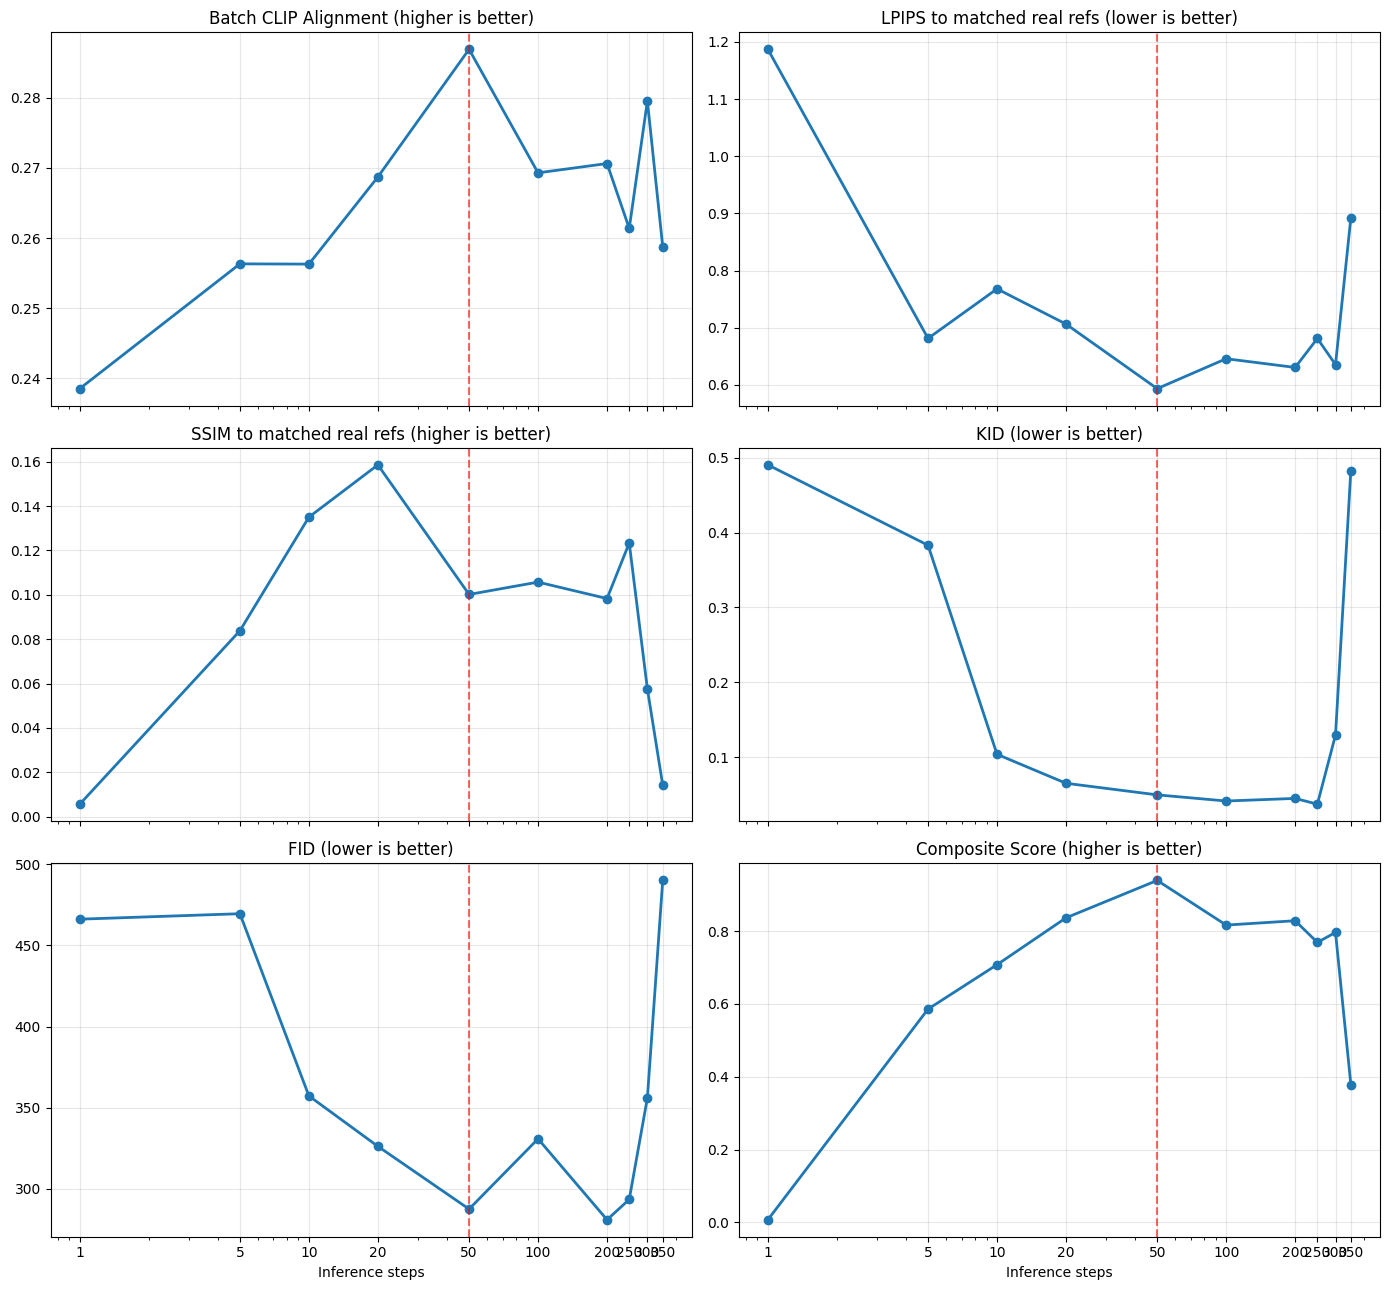

Saved plot: /home/doshlom4/work/final_project/outputs/experiment_3/inference_steps_sweep_perceptual_metrics/plots/perceptual_metrics_vs_steps.png
Saved table: /home/doshlom4/work/final_project/outputs/experiment_3/inference_steps_sweep_perceptual_metrics/tables/perceptual_metrics_ranking.csv
Saved table: /home/doshlom4/work/final_project/outputs/experiment_3/inference_steps_sweep_perceptual_metrics/tables/perceptual_metrics_ranking.json


In [11]:
plot_df = results_df.sort_values("steps").reset_index(drop=True)

fig, axes = plt.subplots(3, 2, figsize=(14, 13), sharex=True)
axes = axes.ravel()
plot_specs = [
    ("clip_mean", "Batch CLIP Alignment", "higher is better"),
    ("lpips_mean", "LPIPS to matched real refs", "lower is better"),
    ("ssim_mean", "SSIM to matched real refs", "higher is better"),
    ("kid_mean", "KID", "lower is better"),
    ("fid", "FID", "lower is better"),
    ("composite_score", "Composite Score", "higher is better"),
]

for ax, (column_name, title, subtitle) in zip(axes, plot_specs):
    ax.plot(plot_df["steps"], plot_df[column_name], marker="o", linewidth=2)
    best_row = plot_df.loc[plot_df["rank"].idxmin()]
    ax.axvline(best_row["steps"], linestyle="--", color="red", alpha=0.6)
    ax.set_title(f"{title} ({subtitle})")
    ax.grid(True, alpha=0.3)
    ax.set_xscale("log")
    ax.set_xticks(plot_df["steps"])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

axes[-2].set_xlabel("Inference steps")
axes[-1].set_xlabel("Inference steps")
plt.tight_layout()
metrics_plot_path = PLOTS_DIR / "perceptual_metrics_vs_steps.png"
plt.savefig(metrics_plot_path, dpi=150, bbox_inches="tight")
plt.show()

csv_path = TABLES_DIR / "perceptual_metrics_ranking.csv"
json_path = TABLES_DIR / "perceptual_metrics_ranking.json"
results_df.to_csv(csv_path, index=False)
results_df.to_json(json_path, orient="records", indent=2)

print(f"Saved plot: {metrics_plot_path}")
print(f"Saved table: {csv_path}")
print(f"Saved table: {json_path}")

## 12. Visual Compare Best, Median, and Worst Step Counts

Render image grids for the highest-ranked, middle-ranked, and lowest-ranked step counts so the quantitative ranking can be checked against what the images actually look like.

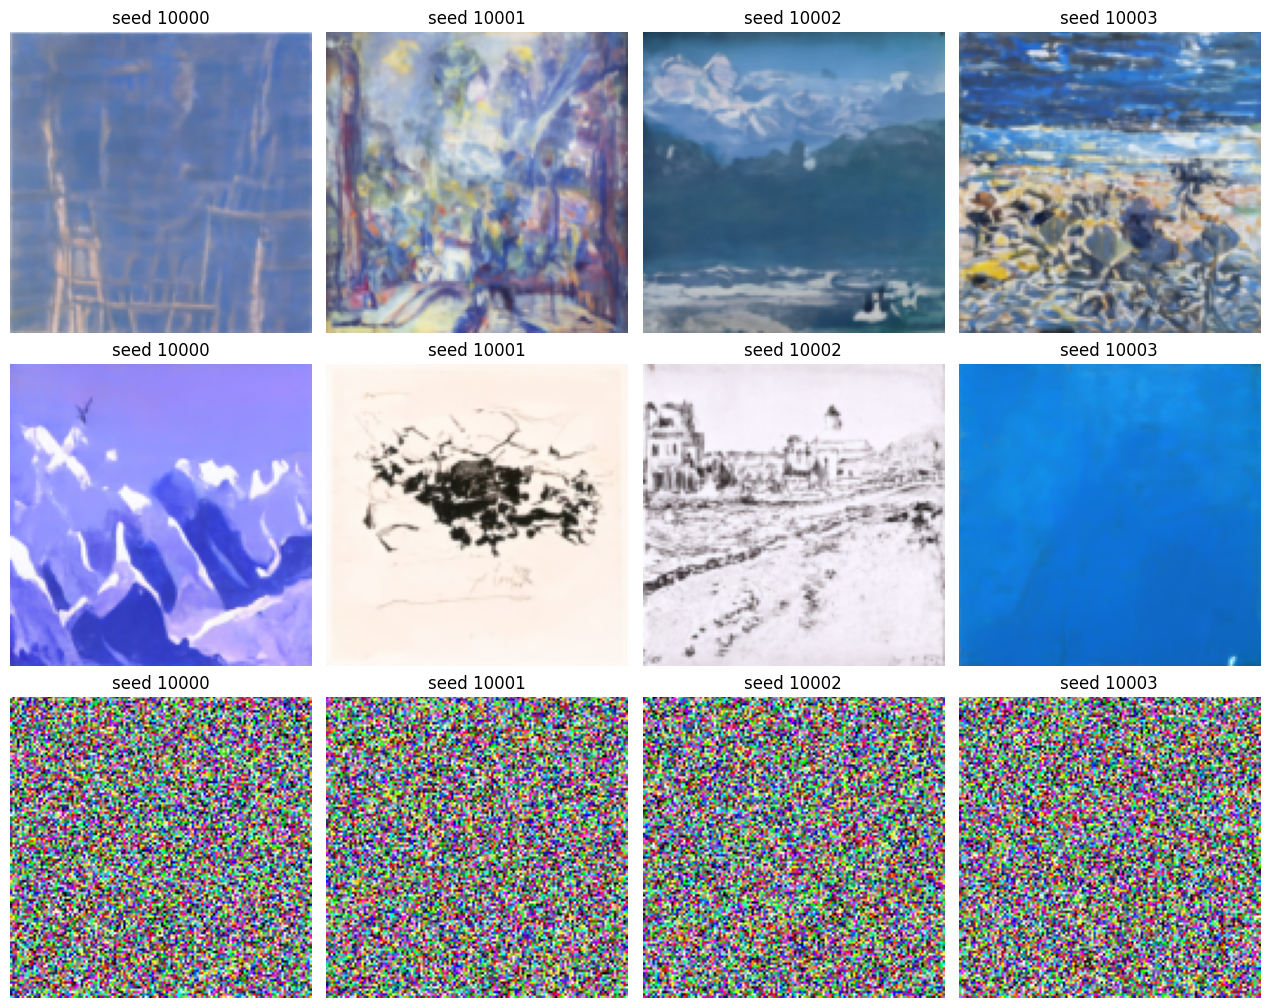

Best steps: 50
Median steps: 250
Worst steps: 1
Saved visual compare: /home/doshlom4/work/final_project/outputs/experiment_3/inference_steps_sweep_perceptual_metrics/plots/best_median_worst_visual_compare.png


In [12]:
ranking_sorted = results_df.sort_values("rank").reset_index(drop=True)
best_steps = int(ranking_sorted.iloc[0]["steps"])
median_steps = int(ranking_sorted.iloc[len(ranking_sorted) // 2]["steps"])
worst_steps = int(ranking_sorted.iloc[-1]["steps"])
selected_steps = [best_steps, median_steps, worst_steps]
selected_labels = ["Best", "Median", "Worst"]

fig, axes = plt.subplots(len(selected_steps), VISUAL_COMPARE_COUNT, figsize=(3.2 * VISUAL_COMPARE_COUNT, 3.4 * len(selected_steps)))
if len(selected_steps) == 1:
    axes = np.array([axes])

for row_idx, (label, num_steps) in enumerate(zip(selected_labels, selected_steps)):
    image_paths = generated_batches[num_steps][:VISUAL_COMPARE_COUNT]
    for col_idx, image_path in enumerate(image_paths):
        ax = axes[row_idx, col_idx]
        ax.imshow(np.asarray(Image.open(image_path).convert("RGB")))
        ax.axis("off")
        if col_idx == 0:
            score = results_df.loc[results_df["steps"] == num_steps, "composite_score"].iloc[0]
            ax.set_ylabel(f"{label}\n{num_steps} steps\nscore={score:.3f}", rotation=0, labelpad=45, va="center")
        ax.set_title(f"seed {EVAL_SEEDS[col_idx]}")

plt.tight_layout()
visual_path = PLOTS_DIR / "best_median_worst_visual_compare.png"
plt.savefig(visual_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Best steps: {best_steps}")
print(f"Median steps: {median_steps}")
print(f"Worst steps: {worst_steps}")
print(f"Saved visual compare: {visual_path}")

## Summary

This notebook evaluates inference-step quality using **batches** rather than a single display image.

### Main interpretation rules

- **CLIP mean**: higher means stronger prompt alignment across the batch
- **Style confidence**: higher means the WikiArt classifier sees the target style more consistently
- **LPIPS to matched real references**: lower means the generated images are perceptually closer to real style examples
- **SSIM to matched real references**: higher means stronger structural similarity to real style examples
- **KID / FID**: lower means the generated batch is closer to the real style distribution
- **TV / clipping ratio**: lower means fewer noise-like or over-saturated artifacts

### Why this should behave better than the old notebook

This notebook is harder to fool because a step count now has to do well on several independent signals at once:

- semantic alignment
- perceptual similarity to real WikiArt references
- distribution quality on the full batch
- artifact suppression

If an extreme step count produces static or noisy images, it will usually suffer on **LPIPS, SSIM, classifier confidence, KID, and artifact penalties**, even if one metric alone looks deceptively good.

### Saved outputs

- plots: `outputs/experiment_3/inference_steps_sweep_perceptual_metrics/plots/`
- tables: `outputs/experiment_3/inference_steps_sweep_perceptual_metrics/tables/`
- cached generated batches: `outputs/experiment_3/inference_steps_sweep_perceptual_metrics/generated/`